# MITGCM Transect Visualization

**Purpose**: Code for visualizing the spatial evolution of the potential density and velocity field. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime, timedelta
import os
import cmocean.cm as cmo
from matplotlib.animation import FuncAnimation, FFMpegWriter
from tqdm import tqdm
from geopy.distance import geodesic
import matplotlib.gridspec as gridspec

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from plotScaleAnalysis import add_freq_marker
from lsf import unweighted_lsf, detrend, compute_amp_phase

Set data analysis parameters

In [3]:
# Specify data processing 
option_lsf = False          # Specifies whether to remove the time-mean, annual cycle, and semi-annual cycle 

# Set time and space parameters  
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_mld = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/supplementary_figs/'
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
fontsize = 18

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load mitgcm data netcdf files 

In [4]:
#-------------------------------------------------------#
# Transect Data
#-------------------------------------------------------# 
filename_tsd = PATH + "mitgcm_intermediate_data_TSD_hrly_transect_profiles.nc"
filename_vel = PATH + "mitgcm_intermediate_data_vel_hrly_transect_profiles.nc"
nc_tsd = Dataset(filename_tsd, 'r')
nc_vel = Dataset(filename_vel, 'r')

# Extract data variables
depth     = nc_tsd.variables['depth'][:]
depth_mid = nc_tsd.variables['depth_mid'][:]
lon       = nc_tsd.variables['LON'][:]
lat       = nc_tsd.variables['LAT'][:]
dist      = nc_tsd.variables['DIST'][:]     
time      =  num2date(nc_tsd.variables['time'][:], nc_tsd.variables['time'].units)

sig = nc_tsd.variables['SIG'][:]
Nz  = nc_tsd.variables['NZ'][:]
u_along_shore = nc_vel.variables['v_cross'][:]
u_cross_shore = nc_vel.variables['u_along'][:]
u_along_shore_bar = nc_vel.variables['v_cross_bar'][:]
u_cross_shore_bar = nc_vel.variables['u_along_bar'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time])

# Flip the distance axis of the data array to match the orientation of the distance coordinates (increasing from left to right)
lon = lon[::-1]
lat = lat[::-1]
sig = sig[::-1,:,:]
Nz = Nz[::-1,:]
u_along_shore = u_along_shore[::-1,:,:]
u_cross_shore = u_cross_shore[::-1,:,:]
u_along_shore_bar = u_along_shore_bar[::-1,:]
u_cross_shore_bar = u_cross_shore_bar[::-1,:]

#-------------------------------------------------------#
# Mixed Layer depth Data
#-------------------------------------------------------#
filename_mld  = PATH_mld + "/mitgcm_transect_mld_climatology.npz"

# Load data 
ds_mld   = np.load(filename_mld, allow_pickle=True)

# Extract data variables
mld                  = ds_mld['mld']                 # Units: meters
mld_monthly_mean     = ds_mld['mld_monthly_mean']    # Units: meters
mld_monthly_var      = ds_mld['mld_monthly_var']     # Units: meters
mld_monthly_stdm     = ds_mld['mld_monthly_stdm'] 
mld_monthly_stdv     = ds_mld['mld_monthly_stdv'] 
lat_mld              = ds_mld['lat'] 
lon_mld              = ds_mld['lon'] 
time_mld             = ds_mld['time']
time_mld_monthly     = ds_mld['time_monthly']

#-------------------------------------------------------#
# Decorrelation scale Data
#-------------------------------------------------------#
filename_decor  = PATH_mld + "/mitgcm_transect_temporal_scale_densityCalCOFI_line80_unc.npz"

# Load data 
ds_decor   = np.load(filename_decor, allow_pickle=True)

# Extract data variables
Lt_days       = ds_decor['Lt_days']         # Units: days
Lt_stdm_days  = ds_decor['Lt_stdm_days']    # Units: days
dist          = ds_decor['dist']            # Units: kilometers
depth         = ds_decor['depth']

Compute cumulative distance along line 80.0 for the mixed layer depth 

In [5]:
# Initialize array 
dist_mld = np.zeros(len(lon_mld))

# Loop through stations 
for i in range(1,len(lon_mld)): 

    # Define i and i + 1 points along transect
    pt1 = (lat_mld[i-1], lon_mld[i-1])
    pt2 = (lat_mld[i],   lon_mld[i])

    # Compute distance in kilometers along transect
    dist_mld[i] = dist_mld[i-1] + geodesic(pt1, pt2).km

# Find the indices specified by lat and lon bounds
dist_mask = ((lat_mld >= lat_bnds[0]) & (lat_mld <= lat_bnds[1]) & (lon_mld >= lon_bnds[0]) & (lon_mld <= lon_bnds[1]))
idx_dist_mld  = np.where(dist_mask)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
lat_mld   = lat_mld[idx_dist_mld]
lon_mld   = lon_mld[idx_dist_mld]
dist_mld  = dist_mld[idx_dist_mld]

Load in the ocean bottom land mask

In [6]:
filename = PATH + "ocean_bottom_CCS4_transect_calCOFI_line80.nc"
nc = Dataset(filename, 'r')

# Extract data variables
bottom_depth = nc.variables['bottom_depth'][:]

# Reverse order of bottom depth 
bottom_depth = bottom_depth[::-1]

Set the locations of each cce mooring

In [7]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53825701527784
lat3 = 34.44825228022894

#--- Shore ---# 
lon_shore = -120.483310
lat_shore = 34.482942

Slice the data so that the analysis only considers the upper 200 meters and offshore distances up to 123 degrees west

In [8]:
# Find the indices for the upper 200 meters and specified lat and lon bounds
dist_mask = ((lat >= lat_bnds[0]) & (lat <= lat_bnds[1]) & (lon >= lon_bnds[0]) & (lon <= lon_bnds[1]))
idx_dist  = np.where(dist_mask)[0]
idx_depth = np.where(depth >= -215)[0]
idx_depth_mid = np.where(depth_mid >= -215)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
depth = depth[idx_depth]
depth_mid = depth_mid[idx_depth_mid]
lat   = lat[idx_dist]
lon   = lon[idx_dist]
dist  = dist[idx_dist]
bottom_depth = bottom_depth[idx_dist]

sig = sig[idx_dist, :, :][:, :, idx_depth]
Nz = Nz[idx_dist, :][:, idx_depth_mid]
u_along_shore = u_along_shore[idx_dist, :, :][:, :, idx_depth]
u_cross_shore = u_cross_shore[idx_dist, :, :][:, :, idx_depth]
u_along_shore_bar = u_along_shore_bar[idx_dist, :]
u_cross_shore_bar = u_cross_shore_bar[idx_dist, :]
mld          = mld[idx_dist,:]
mld_monthly_mean = mld_monthly_mean[idx_dist,:]

Change the order of the sig and velocity arrays

In [9]:
sig = np.transpose(sig, (1, 0, 2))
u_along_shore = np.transpose(u_along_shore, (1, 0, 2))
u_cross_shore = np.transpose(u_cross_shore, (1, 0, 2))
u_along_shore_bar = np.transpose(u_along_shore_bar, (1, 0))
u_cross_shore_bar = np.transpose(u_cross_shore_bar, (1, 0))

Compute the seasonally averaged mixed layer depth 

In [10]:
mld_mean = np.mean(mld_monthly_mean,axis=1)
mld_std  = np.std(mld_monthly_mean,ddof=1,axis=1)

Compute the distance from the final CalCOFI station (closest to shore) and the shore

In [11]:
# Define points 
calcofi_station = (lat[0], lon[0])
shore           = (lat_shore,   lon_shore)

# Compute distance
dist_offset = geodesic(calcofi_station, shore).km

# Apply distance from shore correction
dist_cor     = dist + dist_offset
dist_mld_cor = dist_mld + dist_offset

Compute anomly time series

In [13]:
if option_lsf == True: 

    # Set parameters
    w1, w2        = [(2*np.pi)/31557600, (2)*(2*np.pi)/31557600]      # Radian Frequency for annual and semi-annual cycles. Units: rad/sec

    # Set dimensions     
    ndist,ntime,ndepth = np.shape(sig)

    # Convert to seconds since start time
    t0 = time_dt[0]
    time_elapsed = np.array([(t - t0).total_seconds() for t in time_dt])

    # Initialize arrays 
    sig_anom           = np.ma.masked_all((ndist, ntime, ndepth))
    u_along_shore_anom = np.ma.masked_all((ndist, ntime, ndepth))
    u_cross_shore_anom = np.ma.masked_all((ndist, ntime, ndepth))
    cn_dist = 0 

    # Loop through distance offshore 
    for idist in range(0,ndist):
        
        # Set progress bar
        progress = (idist + 1) / (ndist-1)
        sys.stdout.write(f"\rProgress: {progress:.1%}")
        sys.stdout.flush()

        # Set depth counter 
        cn_depth = 0

        # Loop through depth
        for idepth in range(0,ndepth):
            
            # Initialize the ith time series 
            sig_ts = sig[idist,:,idepth]
            ua_ts  = u_along_shore[idist,:,idepth]
            uc_ts  = u_cross_shore[idist,:,idepth]

            # Try statement to handle masked values associated with land
            try:

                # Fit a mean, annual cycle and semi-annual cycle to the ith time series
                hfit_sig, x_sig, x_sig_sigma, _ = unweighted_lsf(sig_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
                hfit_ua, x_ua, x_ua_sigma, _    = unweighted_lsf(ua_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
                hfit_uc, x_uc, x_uc_sigma, _    = unweighted_lsf(uc_ts, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)

                # Remove the fit from the time series
                sig_anom[idist,:,idepth]           = sig_ts - hfit_sig
                u_along_shore_anom[idist,:,idepth] = ua_ts - hfit_ua
                u_cross_shore_anom[idist,:,idepth] = uc_ts - hfit_uc

            except Exception: 

                # Print warining message 
                print('Masked time series! Skipping grid point.')


Compute the relative uncertainty and mask grid point with a decorrelation scale less than twice its standard error

In [14]:
# Set noise to signal ratio criteria
ns = 10 / 10

# Compute spatial means 
Lt_rho_spatial_mean = np.mean(Lt_days) 

# Compute the relative uncertainty
Lt_rho_rel_unc = Lt_stdm_days / (Lt_days - Lt_rho_spatial_mean)

# Mask not statistically significant grid points
Lt_rho_mask = np.ma.getmask(np.ma.masked_greater_equal(Lt_rho_rel_unc, (ns)))

# Create a mask array where non-significant points = 1, others = NaN
rho_mask = np.where(Lt_rho_mask, 1, np.nan)

Plot the decorrelation time scale for potential density

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_49899/4031542572.py:15: UserWarning: linewidths is ignored by contourf
  ax.contourf(
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_49899/4031542572.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


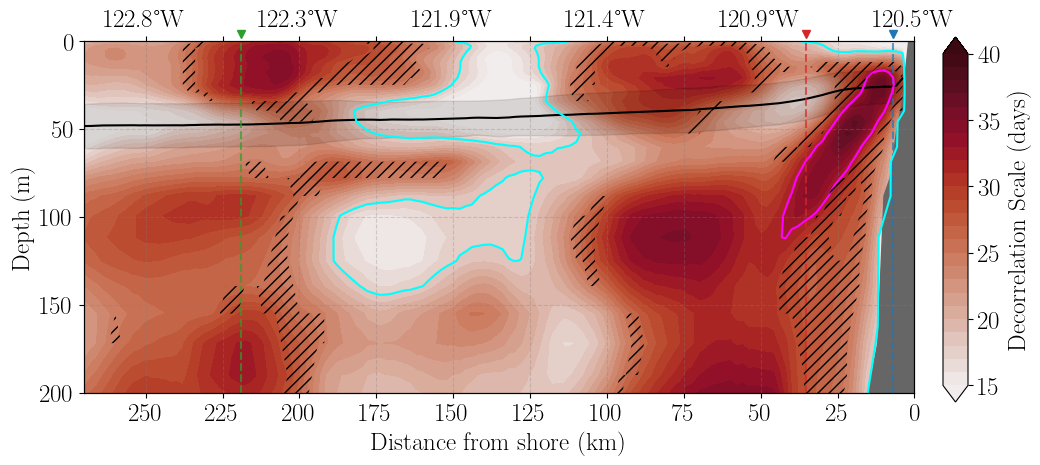

In [15]:
# Set plotting parameter
level = np.arange(15,40+1,1)
levels_decor = [18, 32]
min_points = 53

# Create figure
fig, ax = plt.subplots(figsize=(10,5))

#--- Subplot 1 ---# 

# Plot decorrelation time scale
cf = ax.contourf(dist_cor,abs(depth),Lt_days.T, levels=level, cmap=cmo.amp, extend='both')

# Overlay a contourf with hatching for the non-significant regions
ax.contourf(
    dist_cor,
    abs(depth),
    rho_mask.T,
    levels=[0.5, 1.5],      # anything that spans "1"
    hatches=['///'],        # your preferred hatching style
    colors='none',          # keep underlying colormap visible
    linewidths=0,
    zorder=10,              # ensure it sits above the shading
)

# Plot contours 
# cs = ax.contour(
#     dist_cor, abs(depth), Lt_days.T,
#     levels=levels_decor,
# )

# ---------------------
# Plot and filter decorrelation contours (robust version)
# ---------------------

# 1. Create contours (we immediately extract segments and remove artist)
cs = ax.contour(
    dist_cor, abs(depth), Lt_days.T,
    levels=levels_decor,
)

# 2. Filter segments using allsegs (stable representation)
filtered_segments = []
filtered_levels = []

for i, seg_list in enumerate(cs.allsegs):
    good_segs = [seg for seg in seg_list if len(seg) > min_points]

    if len(good_segs) > 0:
        filtered_segments.append(good_segs)
        filtered_levels.append(levels_decor[i])

# 3. Remove original contour object
cs.remove()

# 4. Re-plot only filtered segments
for lvl_segs, lvl in zip(filtered_segments, filtered_levels):

    color = 'cyan' if lvl == levels_decor[0] else 'magenta'

    for seg in lvl_segs:
        ax.plot(
            seg[:, 0],
            seg[:, 1],
            color=color,
            linewidth=1.5,
            zorder=6
        )

# Plot seasonally averaged mixed layer depth
ax.plot(dist_mld_cor[1:],mld_mean[1:],ls='-', lw=1.5, color='black', markersize=8)

# Plot standard deviation of mixed layer depth 
ax.fill_between(dist_mld_cor[1:], mld_mean[1:] - mld_std[1:], mld_mean[1:] + mld_std[1:], color='black', alpha=0.1)

# Plot the ocean bottom depth 
ax.fill_between(dist_cor, abs(bottom_depth), abs(depth[-1]), color='0.4') 
ax.fill_between(np.array([0,dist_offset]), np.array([200,200]), np.array([0,0]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist_cor[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.96, 0.16, 0.025, 0.73])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_label('Decorrelation Scale (days)')
cbar.set_ticks(np.arange(15,40+5,5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_cor, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_cor[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Display 
plt.tight_layout()
plt.show()


In [21]:
np.shape(time_dt)[0]/2

8830.5

Set user options for the animation

In [68]:
# ---------------------
# User options
# ---------------------
season = "winter"   # "winter" or "spring"
num_days = 3

# Define start dates
if season == "winter":
    start_date = datetime(2016, 12, 1)
elif season == "spring":
    start_date = datetime(2016, 3, 1)
else:
    raise ValueError("season must be 'winter' or 'spring'")

# Duration: 120 days
end_date = start_date + timedelta(days=num_days)

# Find indices within this window
time_mask = (time_dt >= start_date) & (time_dt < end_date)
time_indices = np.where(time_mask)[0]

print(f"Selected {len(time_indices)} hourly time steps")

# ---------------------
# Frame rate control (NO STRIDE)
# ---------------------
target_duration_sec = 90   # 60 for 1 min, 90 for 1.5 min

num_frames = len(time_indices)

fps = 24 #int(np.ceil(num_frames / target_duration_sec))

print(f"Total frames: {num_frames}")
print(f"Using fps: {fps}")
print(f"Video duration: {num_frames / fps:.1f} seconds")

Selected 72 hourly time steps
Total frames: 72
Using fps: 24
Video duration: 3.0 seconds


Create an animation of the potential density field

Rendering frames: 100%|██████████| 72/72 [00:13<00:00,  5.30it/s]


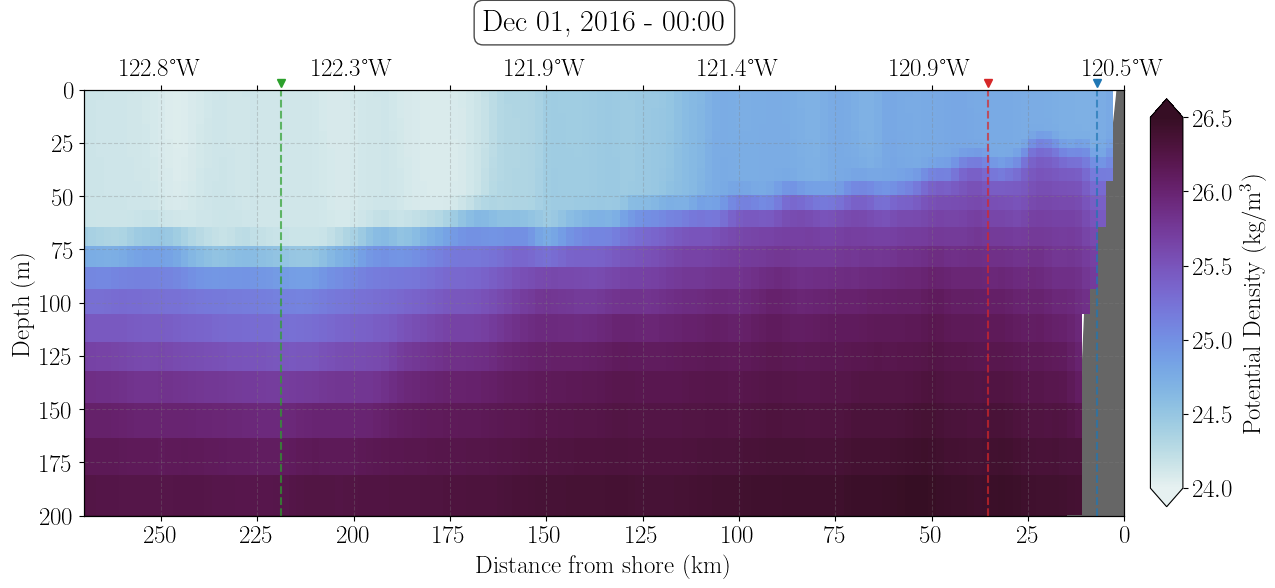

In [71]:
# Set plotting parameters
levels_decor = [18, 32]
vmin, vmax = 24.0, 26.5
cmap = cmo.dense 
frame_indices = time_indices
num_frames = len(frame_indices)
fmt = {16: '16 days', 38: '38 days'}

# Create figure
fig, ax = plt.subplots(figsize=(13,6))

fig.subplots_adjust(
    left=0.08,
    right=0.88,   # leave room for colorbar
    top=0.83,     # leave room for title + top axis
    bottom=0.12
)

# Plot potential density at the first time step to set colorbar
mesh = ax.pcolormesh(dist_cor,abs(depth),sig[0,:,:].T, cmap=cmap, vmin=vmin, vmax= vmax)

# Plot the ocean bottom depth 
ax.fill_between(dist_cor, abs(bottom_depth), abs(depth[-1]), color='0.4') 
ax.fill_between(np.array([0,dist_offset]), np.array([200,200]), np.array([0,0]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist_cor[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Add title 
ax.set_title(
    time_dt[0].strftime('%b %d, %Y - %H:%M'),
    pad=20,
    bbox=dict(
        facecolor='white',
        edgecolor='black',
        boxstyle='round,pad=0.3',
        alpha=0.9
    )
)

# Set colorbar
cax = fig.add_axes([0.90, 0.135, 0.025, 0.68])# [left, bottom, width, height]
cbar = fig.colorbar(mesh, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'Potential Density (kg/m$^3$)')
cbar.set_ticks(np.arange(vmin,vmax+0.5,0.5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_cor, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_cor[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Set mesh variable
mesh = None

# ---------------------
# Animation update function
# ---------------------
def update(frame, sig, time_dt):

    global mesh

    # Set frame indice
    idx = frame_indices[frame] 

    # Remove old mesh ONLY
    if mesh is not None:
        mesh.remove()

    # Title
    ax.set_title(time_dt[idx].strftime('%b %d, %Y - %H:%M'), pad=20, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.7))

    # Plot potential density
    mesh = ax.pcolormesh(dist_cor,abs(depth),sig[idx,:,:].T, cmap=cmap, vmin=vmin, vmax= vmax)

    return []

# ---------------------
# Create animation
# ---------------------
ani = FuncAnimation(
    fig,
    update,
    frames=num_frames,
    fargs=(sig, time_dt),
    blit=False
)

# ---------------------
# Save animation with progress bar
# ---------------------
writer = FFMpegWriter(
    fps=fps,
    metadata={'artist': 'Potential Density'}
)

output_file = PATH_figs + f'sig_transect_variability_{season}_2016_test.mp4'

with writer.saving(fig, output_file, dpi=120):

    for frame in tqdm(range(num_frames), desc="Rendering frames"):

        update(frame, sig, time_dt)
        writer.grab_frame()

Compute magnitude of the spatial gradients of the density

In [89]:
# Convert distance to meters
dist_m = dist * 1000

#---------------------------# 
# Compute spatial gradients 
#---------------------------#

# Compute the along-track (across-shore) gradient at each time step and then average in time
drho_dx = np.gradient(sig, dist_m, axis=1)

# Compute the vertical gradient at each time step and then average in time
drho_dz = np.gradient(sig, depth, axis=2)

# Compute the magnitude of the gradient vector
grad_mag = np.sqrt(drho_dx**2 + drho_dz**2)

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_34733/320842929.py:15: RuntimeWarning: invalid value encountered in sqrt
  grad_mag = np.sqrt(drho_dx**2 + drho_dz**2)


Create an animation of potential density spatial gradient

Rendering frames: 100%|██████████| 72/72 [00:16<00:00,  4.40it/s]


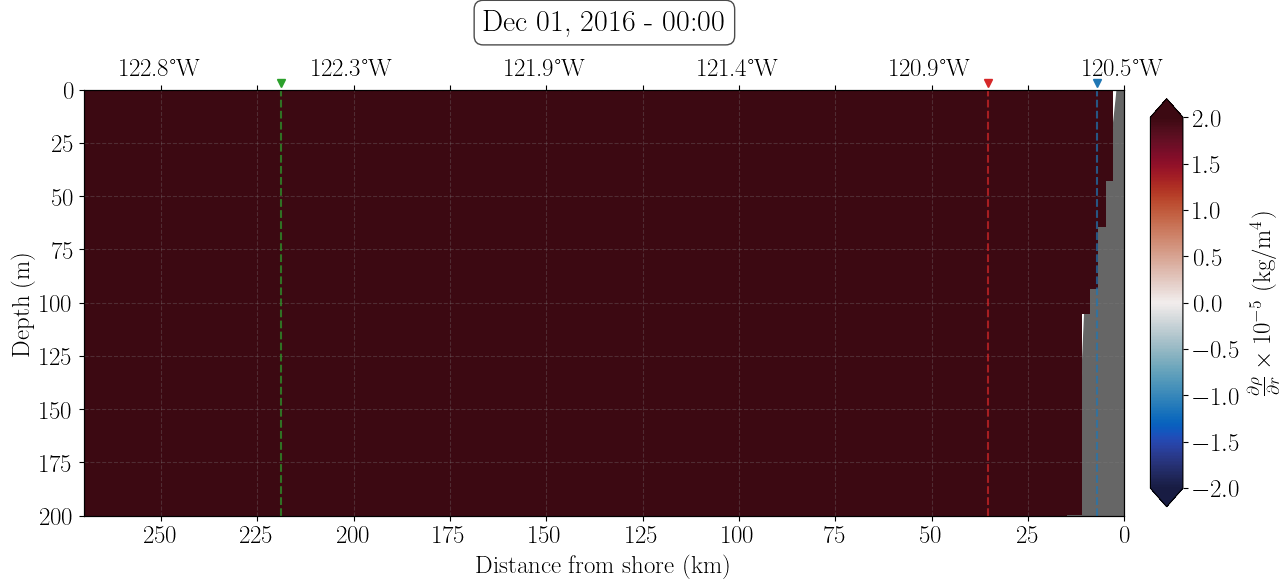

In [103]:
# Set plotting parameters
levels_decor = [18, 32]
vmin, vmax = -2, 2
cmap = cmo.balance 
frame_indices = time_indices
num_frames = len(frame_indices)
fmt = {18: '16 days', 32: '32 days'}

# Create figure
fig, ax = plt.subplots(figsize=(13,6))

fig.subplots_adjust(
    left=0.08,
    right=0.88,   # leave room for colorbar
    top=0.83,     # leave room for title + top axis
    bottom=0.12
)

# Plot potential density at the first time step to set colorbar
mesh = ax.pcolormesh(dist_cor,abs(depth),(drho_dx[0,:,:]*10**5).T, cmap=cmap, vmin=vmin, vmax= vmax)

# Plot the ocean bottom depth 
ax.fill_between(dist_cor, abs(bottom_depth), abs(depth[-1]), color='0.4') 
ax.fill_between(np.array([0,dist_offset]), np.array([200,200]), np.array([0,0]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist_cor[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Add title 
ax.set_title(
    time_dt[0].strftime('%b %d, %Y - %H:%M'),
    pad=20,
    bbox=dict(
        facecolor='white',
        edgecolor='black',
        boxstyle='round,pad=0.3',
        alpha=0.9
    )
)

# Set colorbar
cax = fig.add_axes([0.90, 0.135, 0.025, 0.68])# [left, bottom, width, height]
cbar = fig.colorbar(mesh, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'$\frac{\partial \rho}{\partial r} \times 10^{-5}$ (kg/m$^4$)')
cbar.set_ticks(np.arange(vmin,vmax+0.5,0.5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_cor, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_cor[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Set mesh variable
mesh = None

# ---------------------
# Animation update function
# ---------------------
def update(frame, drho_dx, time_dt):

    global mesh

    # Set frame indice
    idx = frame_indices[frame] 

    # Remove old mesh ONLY
    if mesh is not None:
        mesh.remove()

    # Title
    ax.set_title(time_dt[idx].strftime('%b %d, %Y - %H:%M'), pad=20, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.7))

    # Plot potential density
    mesh = ax.pcolormesh(dist_cor,abs(depth),(drho_dx[idx,:,:]*10**5).T, cmap=cmap, vmin=vmin, vmax= vmax)

    return []

# ---------------------
# Create animation
# ---------------------
ani = FuncAnimation(
    fig,
    update,
    frames=num_frames,
    fargs=(sig, time_dt),
    blit=False
)

# ---------------------
# Save animation with progress bar
# ---------------------
writer = FFMpegWriter(
    fps=fps,
    metadata={'artist': 'Potential Density'}
)

output_file = PATH_figs + f'grad_sig_along_transect_variability_{season}_2016.mp4'

with writer.saving(fig, output_file, dpi=120):

    for frame in tqdm(range(num_frames), desc="Rendering frames"):

        update(frame, drho_dx, time_dt)
        writer.grab_frame()

Rendering frames: 100%|██████████| 72/72 [00:11<00:00,  6.10it/s]


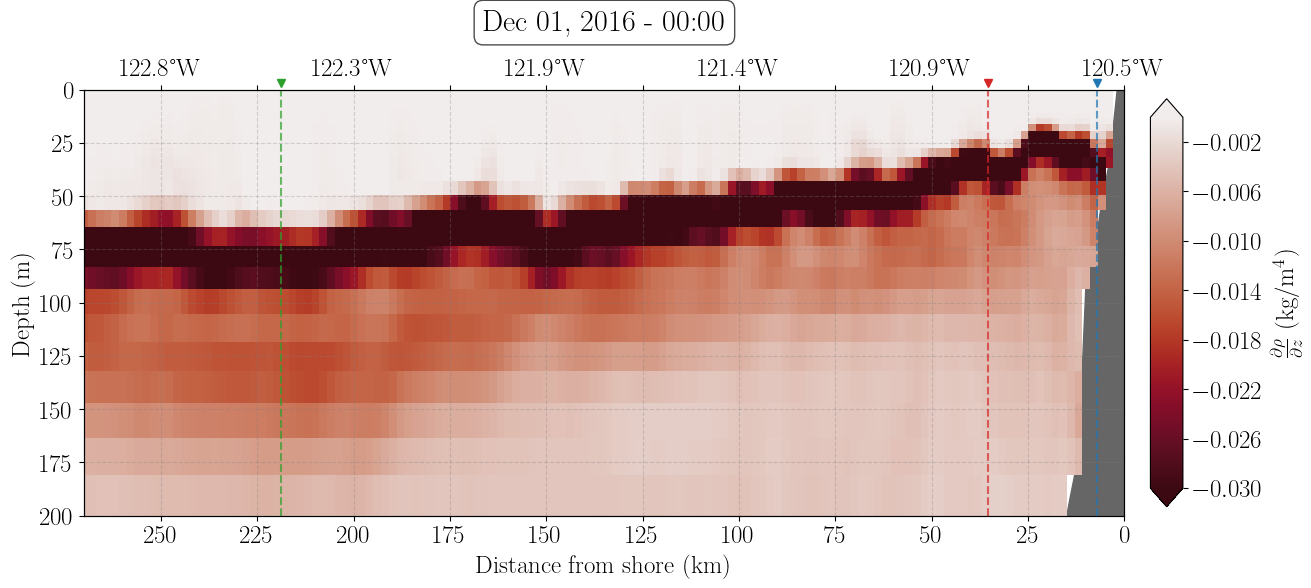

In [102]:
# Set plotting parameters
levels_decor = [18, 32]
vmin, vmax = -0.03, 0
cmap = cmo.amp_r 
frame_indices = time_indices
num_frames = len(frame_indices)
fmt = {18: '16 days', 32: '32 days'}

# Create figure
fig, ax = plt.subplots(figsize=(13,6))

fig.subplots_adjust(
    left=0.08,
    right=0.88,   # leave room for colorbar
    top=0.83,     # leave room for title + top axis
    bottom=0.12
)

# Plot potential density at the first time step to set colorbar
mesh = ax.pcolormesh(dist_cor,abs(depth),(drho_dz[0,:,:]).T, cmap=cmap, vmin=vmin, vmax= vmax)

# Plot the ocean bottom depth 
ax.fill_between(dist_cor, abs(bottom_depth), abs(depth[-1]), color='0.4') 
ax.fill_between(np.array([0,dist_offset]), np.array([200,200]), np.array([0,0]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist_cor[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Add title 
ax.set_title(
    time_dt[0].strftime('%b %d, %Y - %H:%M'),
    pad=20,
    bbox=dict(
        facecolor='white',
        edgecolor='black',
        boxstyle='round,pad=0.3',
        alpha=0.9
    )
)

# Set colorbar
cax = fig.add_axes([0.90, 0.135, 0.025, 0.68])# [left, bottom, width, height]
cbar = fig.colorbar(mesh, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'$\frac{\partial \rho}{\partial z}$ (kg/m$^4$)')
cbar.set_ticks(np.arange(vmin,vmax,0.004))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_cor, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_cor[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Set mesh variable
mesh = None

# ---------------------
# Animation update function
# ---------------------
def update(frame, drho_dx, time_dt):

    global mesh

    # Set frame indice
    idx = frame_indices[frame] 

    # Remove old mesh ONLY
    if mesh is not None:
        mesh.remove()

    # Title
    ax.set_title(time_dt[idx].strftime('%b %d, %Y - %H:%M'), pad=20, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.7))

    # Plot potential density
    mesh = ax.pcolormesh(dist_cor,abs(depth),(drho_dz[idx,:,:]).T, cmap=cmap, vmin=vmin, vmax= vmax)

    return []

# ---------------------
# Create animation
# ---------------------
ani = FuncAnimation(
    fig,
    update,
    frames=num_frames,
    fargs=(sig, time_dt),
    blit=False
)

# ---------------------
# Save animation with progress bar
# ---------------------
writer = FFMpegWriter(
    fps=fps,
    metadata={'artist': 'Potential Density'}
)

output_file = PATH_figs + f'grad_sig_vert_transect_variability_{season}_2016.mp4'

with writer.saving(fig, output_file, dpi=120):

    for frame in tqdm(range(num_frames), desc="Rendering frames"):

        update(frame, drho_dx, time_dt)
        writer.grab_frame()

Create an animation of potential density with the depth averaged velocity 

In [ ]:
# Create figure
fig = plt.figure(figsize=(10,8))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 2]) 

#--- Subplot 1 ---# 
ax = fig.add_subplot(gs[0])

# Plot the velocity vectors
q = ax.quiver(dist, np.zeros_like(dist), u_cross_bar_mean, u_along_bar_mean, scale=1, width=0.001)

# Set axis attributes
ax.set_xlim(dist[0], dist[-1])
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks([])
#ax.set_xlabel('Distance from shore (km)')
ax.tick_params(top=True, bottom=True, left=False, right=False,
            direction='out', length=3.5)
ax.grid(True, linestyle='--')
ax.invert_xaxis()

# Add coordinate system arrows in top subplot
arrow_length_x,arrow_length_y = 0.02, 0.12  # adjust based on scale of your plot
x0, y0 = 0.06, 0.7    # location in axis coordinates (0–1)

# Add arrows using annotation in axis coordinates
ax.annotate('', xy=(x0 + arrow_length_x, y0), xytext=(x0, y0),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(facecolor='black', width=0.5, headwidth=3, headlength=3))
ax.text(x0 + arrow_length_x + 0.01, y0, 'Cross-shore', transform=ax.transAxes,
        verticalalignment='center', fontsize=8)

ax.annotate('', xy=(x0, y0 + arrow_length_y), xytext=(x0, y0),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(facecolor='black', width=0.5, headwidth=3, headlength=3))
ax.text(x0, y0 + arrow_length_y + 0.03, 'Along-shore', transform=ax.transAxes,
        horizontalalignment='center', fontsize=8)

# Set quiver legend
ax.quiverkey(q, X=0.75, Y=0.2, U=0.1, label='0.1 m/s', labelpos='E', coordinates='axes',fontproperties={'size': 12})

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove bottom x-axis ticklabels
ax.set_xticklabels([])

#--- Subplot 1 ---# 
ax = fig.add_subplot(gs[1])

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),(FKE_tot*100).T, levels=levels_tot, cmap=cmo.thermal, extend='both')

# # Plot seasonally averaged mixed layer depth
# ax.plot(dist_mld_cor[1:],mld_mean[1:],ls='-', lw=1.5, color='black', markersize=8)

# # Plot standard deviation of mixed layer depth 
# ax.fill_between(dist_mld_cor[1:], mld_mean[1:] - mld_std[1:], mld_mean[1:] + mld_std[1:], color='black', alpha=0.1)

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.425, 0.022, 0.28])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical') 
cbar.set_label(r'Total FKE ($\%$)')
cbar.set_ticks(np.arange(5,40+5,5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top and bottom x-axis ticklabels
ax.set_xticklabels([])
ax_top.set_xticklabels([])

#--- Subplot 2 ---# 
ax = fig.add_subplot(gs[2])

# Plot time-mean data
cf = ax.contourf(dist,abs(depth),(FKE_bc*100).T, levels=levels_bc, cmap=cmo.thermal, extend='both')

# Plot seasonally averaged mixed layer depth
ax.plot(dist_mld_cor[1:],mld_mean[1:],ls='-', lw=1.5, color='black', markersize=8)

# Plot standard deviation of mixed layer depth 
ax.fill_between(dist_mld_cor[1:], mld_mean[1:] - mld_std[1:], mld_mean[1:] + mld_std[1:], color='black', alpha=0.1)

# Plot the ocean bottom depth 
ax.fill_between(dist, abs(bottom_depth), abs(depth[-1]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.set_yticks(np.arange(0,200+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Set colorbar
cax = fig.add_axes([0.92, 0.11, 0.022, 0.28])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(r'Baroclinic FKE ($\%$)')
cbar.set_ticks(np.arange(30,80+10,10))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.02, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Remove top x-axis ticklabels
ax_top.set_xticklabels([])

# Display 
plt.subplots_adjust(hspace=0.1, wspace=0.1)
plt.show()

# Save with high quality
# figName = 'figS07.png'

# fig.savefig(
#     PATH_figs + figName,
#     dpi=300,
#     facecolor='white',
#     bbox_inches='tight',
#     pad_inches=0.1,
#     transparent=False
# )


In [ ]:
# Set plotting parameters
levels_decor = [18, 32]
cmap = cmo.dense 
frame_indices = time_indices
num_frames = len(frame_indices)
fmt = {16: '16 days', 38: '38 days'}

# Create figure
fig, ax = plt.subplots(figsize=(13,6))

fig.subplots_adjust(
    left=0.08,
    right=0.88,   # leave room for colorbar
    top=0.83,     # leave room for title + top axis
    bottom=0.12
)

# Plot potential density at the first time step to set colorbar
mesh = ax.pcolormesh(dist_cor,abs(depth),sig[0,:,:].T, cmap=cmap, vmin=24.0, vmax= 27.0)

# Plot the ocean bottom depth 
ax.fill_between(dist_cor, abs(bottom_depth), abs(depth[-1]), color='0.4') 
ax.fill_between(np.array([0,dist_offset]), np.array([200,200]), np.array([0,0]), color='0.4') 

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel('Depth (m)')
ax.set_xlim(0,dist_cor[-1])
ax.set_ylim(0,200)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# Add title 
ax.set_title(
    time_dt[0].strftime('%b %d, %Y - %H:%M'),
    pad=20,
    bbox=dict(
        facecolor='white',
        edgecolor='black',
        boxstyle='round,pad=0.3',
        alpha=0.9
    )
)

# Set colorbar
cax = fig.add_axes([0.90, 0.135, 0.025, 0.68])# [left, bottom, width, height]
cbar = fig.colorbar(mesh, cax=cax, orientation='vertical', extend='both')
cbar.set_label(r'Potential Density (kg/m$^3$)')
cbar.set_ticks(np.arange(24.0,27.0+0.5,0.5))

# --- Create top axis for longitude --- #
ax_top = ax.twiny()

# Make sure limits match
ax_top.set_xlim(ax.get_xlim())

# Choose where you want longitude ticks (same positions as distance ticks)
dist_ticks = ax.get_xticks()

# Interpolate longitude at those distance values
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_cor, lon_180)

# Create labels but only keep every other one
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set ticks and labels
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels) 

sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_cor[sort_idx]

# Interpolate longtiude onto distance coordinates 
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

# Add CCE1, CCE2, and CCE3 locations 
add_freq_marker(ax_top, dist1, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:green',markeredgecolor='tab:green')
add_freq_marker(ax_top, dist2, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:red',markeredgecolor='tab:red')
add_freq_marker(ax_top, dist3, '', y_marker=1.015, y_text=1.035,fontsize=14,markerfacecolor='tab:blue',markeredgecolor='tab:blue')

# Plot vertical lines at CCE1, CCE2, and CCE3 locations
ax.axvline(dist1, color='tab:green', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist2, color='tab:red', linestyle='--', lw=1.5, alpha=0.7)
ax.axvline(dist3, color='tab:blue', linestyle='--', lw=1.5, alpha=0.7)

# Set mesh variable
mesh = None

# ---------------------
# Animation update function
# ---------------------
def update(frame, sig, time_dt):

    global mesh

    # Set frame indice
    idx = frame_indices[frame] 

    # Remove old mesh ONLY
    if mesh is not None:
        mesh.remove()

    # Title
    ax.set_title(time_dt[idx].strftime('%b %d, %Y - %H:%M'), pad=20, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.7))

    # Plot potential density
    mesh = ax.pcolormesh(dist_cor,abs(depth),sig[idx,:,:].T, cmap=cmap, vmin=24.0, vmax= 27.0)

    return []

# ---------------------
# Create animation
# ---------------------
ani = FuncAnimation(
    fig,
    update,
    frames=num_frames,
    fargs=(sig, time_dt),
    blit=False
)

# ---------------------
# Save animation with progress bar
# ---------------------
writer = FFMpegWriter(
    fps=fps,
    metadata={'artist': 'Potential Density'}
)

output_file = PATH_figs + f'sig_transect_variability_{season}_2016.mp4'

with writer.saving(fig, output_file, dpi=120):

    for frame in tqdm(range(num_frames), desc="Rendering frames"):

        update(frame, sig, time_dt)
        writer.grab_frame()